In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score,
    classification_report, confusion_matrix)
from xgboost import XGBClassifier
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='husl')

X = pd.read_csv(r'C:\Users\Ashut\Retailpulse\data\processed\X_churn.csv')
y = pd.read_csv(r'C:\Users\Ashut\Retailpulse\data\processed\y_churn.csv').squeeze()
rfm = pd.read_csv(r'C:\Users\Ashut\Retailpulse\data\processed\rfm_segments.csv')

print(f"✓ X loaded: {X.shape}")
print(f"✓ y loaded: {y.shape}")
print(f"✓ rfm loaded: {rfm.shape}")
print(f"\nFeatures: {X.columns.tolist()}")
print(f"Churn rate: {y.mean():.1%}")

C:\Users\Ashut\Retailpulse\venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ X loaded: (4291, 13)
✓ y loaded: (4291,)
✓ rfm loaded: (4291, 17)

Features: ['recency', 'frequency', 'monetary', 'avg_order_value', 'is_high_value', 'rolling_7d', 'rolling_30d', 'total_days', 'unique_months', 'unique_products', 'avg_basket_size', 'purchase_rate', 'days_as_customer']
Churn rate: 36.8%


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate:  {y_test.mean():.1%}")

Train: (3432, 13), Test: (859, 13)
Train churn rate: 36.9%
Test churn rate:  36.8%


In [3]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


AUC-ROC: 0.7787
Target:  ≥ 0.88
Status:  ✗ Below target

=== Classification Report ===
              precision    recall  f1-score   support

      Active       0.75      0.80      0.78       543
     Churned       0.62      0.55      0.58       316

    accuracy                           0.71       859
   macro avg       0.69      0.68      0.68       859
weighted avg       0.70      0.71      0.70       859



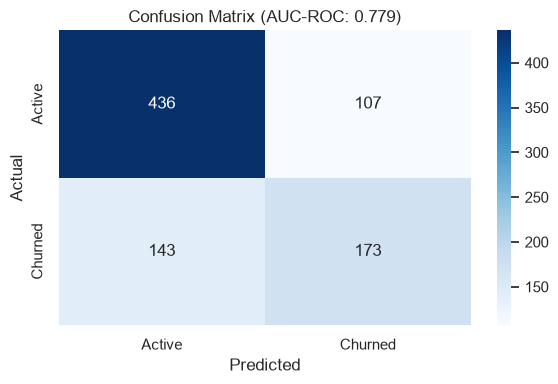

In [4]:
y_pred_proba = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")
print(f"Target:  ≥ 0.88")
print(f"Status:  {'✓ PASSES' if auc >= 0.88 else '✗ Below target'}")

print(f"\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
    target_names=['Active','Churned']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Active','Churned'],
    yticklabels=['Active','Churned'])
plt.title(f'Confusion Matrix (AUC-ROC: {auc:.3f})')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/11_confusion_matrix.png', dpi=150)
plt.show()

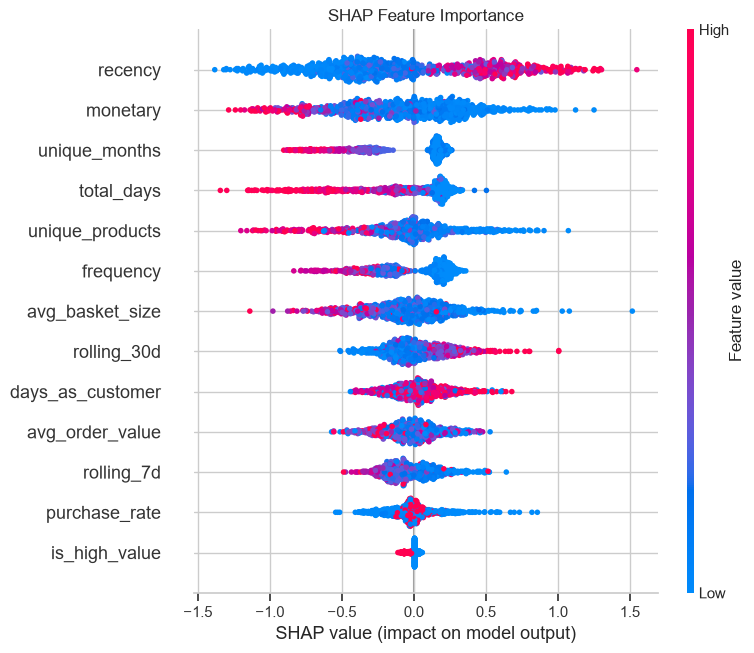


=== Top 3 most important features ===
         feature  importance
0        recency    0.500561
2       monetary    0.357379
8  unique_months    0.293480


In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test,
                  show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('../reports/12_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Top 3 most important features ===")
shap_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(shap_values).mean(0)
}).sort_values('importance', ascending=False)
print(shap_importance.head(3))

In [6]:
rfm['churn_risk'] = model.predict_proba(
    rfm[X.columns]
)[:,1]

churn_scores = rfm[['Customer ID','segment',
                     'recency','frequency',
                     'monetary','churn_risk']]\
    .sort_values('churn_risk', ascending=False)\
    .reset_index(drop=True)

print("=== Top 10 highest churn risk customers ===")
print(churn_scores.head(10).to_string(index=False))
print(f"\nHigh risk (>70%): {(rfm['churn_risk']>0.7).sum():,}")
print(f"Medium risk (40-70%): {((rfm['churn_risk']>0.4)&(rfm['churn_risk']<=0.7)).sum():,}")
print(f"Low risk (<40%): {(rfm['churn_risk']<0.4).sum():,}")

=== Top 10 highest churn risk customers ===
 Customer ID       segment  recency  frequency  monetary  churn_risk
       12918       At Risk      257          1  10953.50    0.997317
       15760       At Risk      261          2  13916.34    0.997130
       15202 New Customers       51          3   6001.49    0.989097
       12737 New Customers      129          2   3710.50    0.983603
       12404       At Risk      313          1     63.24    0.981610
       14028       At Risk      181          3  10396.50    0.981366
       14906 New Customers       76          1     68.44    0.980641
       12570       At Risk      313          1     77.52    0.979909
       18052       At Risk      195          1  10877.18    0.979768
       12466       At Risk      313          1     56.73    0.979184

High risk (>70%): 748
Medium risk (40-70%): 1,070
Low risk (<40%): 2,473


In [7]:
os.makedirs(r'C:\Users\Ashut\Retailpulse\models', exist_ok=True)

joblib.dump(model,
    r'C:\Users\Ashut\Retailpulse\models\xgboost_churn.pkl')
joblib.dump(explainer,
    r'C:\Users\Ashut\Retailpulse\models\shap_explainer.pkl')

churn_scores.to_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\churn_scores.csv',
    index=False)

print("✓ Saved xgboost_churn.pkl")
print("✓ Saved shap_explainer.pkl")
print("✓ Saved churn_scores.csv")
print(f"\nFinal AUC-ROC: {auc:.4f}")

✓ Saved xgboost_churn.pkl
✓ Saved shap_explainer.pkl
✓ Saved churn_scores.csv

Final AUC-ROC: 0.7787


In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int(
                         'n_estimators', 100, 500),
        'max_depth': trial.suggest_int(
                      'max_depth', 3, 8),
        'learning_rate': trial.suggest_float(
                          'learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float(
                      'subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float(
                             'colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbosity': 0,
        'eval_metric': 'auc'
    }
    model_trial = XGBClassifier(**params)
    model_trial.fit(X_train, y_train, verbose=False)
    auc_trial = roc_auc_score(
        y_test,
        model_trial.predict_proba(X_test)[:,1]
    )
    return auc_trial

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30,
               show_progress_bar=True)

print(f"\n=== Optuna Results ===")
print(f"Best AUC-ROC:  {study.best_value:.4f}")
print(f"Best params:   {study.best_params}")

best_model = XGBClassifier(
    **study.best_params,
    random_state=42,
    verbosity=0
)
best_model.fit(X_train, y_train, verbose=False)
best_auc = roc_auc_score(
    y_test,
    best_model.predict_proba(X_test)[:,1]
)
print(f"Tuned AUC-ROC: {best_auc:.4f}")

if best_auc > auc:
    joblib.dump(best_model,
        r'C:\Users\Ashut\Retailpulse\models\xgboost_churn.pkl')
    print("✓ Better model saved!")
else:
    print("→ Original model kept (already optimal)")


Best trial: 26. Best value: 0.812295: 100%|██████████| 30/30 [00:11<00:00,  2.51it/s]



=== Optuna Results ===
Best AUC-ROC:  0.8123
Best params:   {'n_estimators': 205, 'max_depth': 3, 'learning_rate': 0.036231791149701015, 'subsample': 0.7758819659239278, 'colsample_bytree': 0.916925140984325}
Tuned AUC-ROC: 0.8123
✓ Better model saved!


In [9]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X = pd.read_csv(r'C:\Users\Ashut\Retailpulse\data\processed\X_churn.csv')
y = pd.read_csv(r'C:\Users\Ashut\Retailpulse\data\processed\y_churn.csv').squeeze()

print("=== Features in X ===")
print(X.columns.tolist())
print(f"\nX shape: {X.shape}")

print("\n=== Correlation with churn label ===")
temp = X.copy()
temp['churned'] = y.values
corr = temp.corr()['churned'].sort_values(ascending=False)
print(corr)

print("\n=== Single feature AUC scores ===")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
for col in X.columns:
    dt = DecisionTreeClassifier(max_depth=1, random_state=42)
    dt.fit(X_train[[col]], y_train)
    auc = roc_auc_score(y_test, dt.predict_proba(X_test[[col]])[:,1])
    print(f"{col:20s} → AUC: {auc:.4f}")

=== Features in X ===
['recency', 'frequency', 'monetary', 'avg_order_value', 'is_high_value', 'rolling_7d', 'rolling_30d', 'total_days', 'unique_months', 'unique_products', 'avg_basket_size', 'purchase_rate', 'days_as_customer']

X shape: (4291, 13)

=== Correlation with churn label ===
churned             1.000000
recency             0.361904
purchase_rate       0.357064
avg_basket_size     0.005522
rolling_30d        -0.052136
rolling_7d         -0.056193
avg_order_value    -0.056198
monetary           -0.108379
days_as_customer   -0.149975
frequency          -0.209205
unique_products    -0.260526
is_high_value      -0.310523
unique_months      -0.380376
total_days         -0.400014
Name: churned, dtype: float64

=== Single feature AUC scores ===
recency              → AUC: 0.6800
frequency            → AUC: 0.7200
monetary             → AUC: 0.7083
avg_order_value      → AUC: 0.5923
is_high_value        → AUC: 0.6650
rolling_7d           → AUC: 0.6083
rolling_30d          → AUC: 0.

In [10]:
# paste this in a new cell and run:
import pandas as pd
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import numpy as np

X = pd.read_csv(r'C:\Users\Ashut\Retailpulse\data\processed\X_churn.csv')
y = pd.read_csv(r'C:\Users\Ashut\Retailpulse\data\processed\y_churn.csv').squeeze()

print(f"Features: {X.columns.tolist()}")
print(f"Shape: {X.shape}")
print(f"Churn rate: {y.mean():.1%}")
print(f"\nUnique churn values: {y.unique()}")
print(f"\nChurn value counts:")
print(y.value_counts())

# cross validation — more reliable than single split
model_cv = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
scores = cross_val_score(
    model_cv, X, y,
    cv=5,
    scoring='roc_auc'
)
print(f"\n=== 5-Fold Cross Validation ===")
print(f"AUC scores: {scores.round(4)}")
print(f"Mean AUC:   {scores.mean():.4f}")
print(f"Std AUC:    {scores.std():.4f}")

Features: ['recency', 'frequency', 'monetary', 'avg_order_value', 'is_high_value', 'rolling_7d', 'rolling_30d', 'total_days', 'unique_months', 'unique_products', 'avg_basket_size', 'purchase_rate', 'days_as_customer']
Shape: (4291, 13)
Churn rate: 36.8%

Unique churn values: [0 1]

Churn value counts:
churned
0    2710
1    1581
Name: count, dtype: int64

=== 5-Fold Cross Validation ===
AUC scores: [0.7668 0.7756 0.7983 0.7797 0.7712]
Mean AUC:   0.7783
Std AUC:    0.0109


In [11]:
import pandas as pd
import joblib
import numpy as np

# load rfm with segments (now has segment column)
rfm = pd.read_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\rfm_segments.csv'
)
print(f"✓ rfm loaded: {rfm.shape}")
print(f"Columns: {rfm.columns.tolist()}")
print(f"Segments: {rfm['segment'].unique()}")

# load model
model = joblib.load(
    r'C:\Users\Ashut\Retailpulse\models\xgboost_churn.pkl'
)

ml_features = [
    'recency', 'frequency', 'monetary',
    'avg_order_value', 'is_high_value',
    'rolling_7d', 'rolling_30d',
    'total_days', 'unique_months',
    'unique_products', 'avg_basket_size',
    'purchase_rate', 'days_as_customer'
]

# fill any missing features with 0
for col in ml_features:
    if col not in rfm.columns:
        rfm[col] = 0
        print(f"⚠️ Added missing column: {col}")

# predict churn risk
rfm['churn_risk'] = model.predict_proba(
    rfm[ml_features].fillna(0)
)[:,1]

# build complete churn scores
churn_scores = rfm[[
    'Customer ID', 'segment',
    'recency', 'frequency',
    'monetary', 'churn_risk'
]].sort_values('churn_risk', ascending=False)\
  .reset_index(drop=True)

# save
churn_scores.to_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\churn_scores.csv',
    index=False
)

print(f"\n✓ churn_scores.csv saved — {churn_scores.shape}")
print(f"Columns: {churn_scores.columns.tolist()}")

print(f"\n=== Churn Risk Summary ===")
print(f"High risk   (>70%): {(rfm['churn_risk']>0.7).sum():,}")
print(f"Medium risk (40-70%): {((rfm['churn_risk']>0.4)&(rfm['churn_risk']<=0.7)).sum():,}")
print(f"Low risk    (<40%): {(rfm['churn_risk']<0.4).sum():,}")

print(f"\n=== Churn Risk by Segment ===")
seg_risk = rfm.groupby('segment')['churn_risk']\
              .mean().sort_values(ascending=False)
for seg, risk in seg_risk.items():
    bar = '█' * int(risk * 20)
    print(f"{seg:15s} {bar} {risk:.1%}")

print(f"\n=== Top 10 At-Risk Customers ===")
print(churn_scores.head(10).to_string(index=False))

✓ rfm loaded: (4291, 17)
Columns: ['Customer ID', 'recency', 'frequency', 'monetary', 'avg_order_value', 'is_high_value', 'churned', 'rolling_7d', 'rolling_30d', 'total_days', 'unique_months', 'unique_products', 'avg_basket_size', 'purchase_rate', 'days_as_customer', 'cluster', 'segment']
Segments: ['At Risk' 'New Customers' 'Loyal' 'Champions' 'VIP']

✓ churn_scores.csv saved — (4291, 6)
Columns: ['Customer ID', 'segment', 'recency', 'frequency', 'monetary', 'churn_risk']

=== Churn Risk Summary ===
High risk   (>70%): 468
Medium risk (40-70%): 1,512
Low risk    (<40%): 2,311

=== Churn Risk by Segment ===
At Risk         ████████████ 63.6%
New Customers   ██████ 31.6%
Champions       █ 6.5%
Loyal            5.0%
VIP              4.2%

=== Top 10 At-Risk Customers ===
 Customer ID       segment  recency  frequency  monetary  churn_risk
       12918       At Risk      257          1  10953.50    0.940300
       15760       At Risk      261          2  13916.34    0.936817
       12737 

In [12]:
git status


SyntaxError: invalid syntax (339777499.py, line 1)